---
>「人生は選択の連続であるが、一番重要な選択は、あなたの心の内でおこなわれる選択である」\
>ジョセフ・マーフィー
---

# AutoEncoder

AutoEncoderは、入力と出力からなるNNであるが、各層のノード数が途中少なくなるように構成されている

- 入力と出力を同じデータで学習させる、つまり入力と出力が同じデータとなるように学習が進む

- それは簡単にできるであろうと思うが、途中の層は**ノード数が少ない**ことに注目する

  - この隠れ層から入力毎に出力される値の表現空間(潜在空間:Latent Spaceとよぶ)は、学習に使ったデータを**圧縮した**情報を持つといえる
  - ノード数が減っているので、次元が削減されている

図において、特に圧縮された特徴表現を有する隠れ層が表現する変数空間$z$を潜在変数および潜在空間と呼び、そこに至る圧縮ネットワークをエンコーダ、その後ろの展開ネットワークをデコーダと呼ぶ

<img src="http://class.west.sd.keio.ac.jp/dataai/text/autoencoder.jpg" width=400>

例えば、StyleGANも潜在空間を操作して顔を生成できるが、AutoEncoderそのものではない
- 通常のAutoEncoderは、潜在空間のどこへ乱数を置いても自然な画像が出ることを保証しない

- 実際の形とは異なるが、次のように考えるとよい
- 顔画像を入力し同じ顔画像を生成するように学習させた後、エンコーダを取り外しデコーダだけを利用すれば、$z$に学習済みの表現を与えて画像を生成することを考えられる自然な乱数生成を扱うために、後述のVAEなどを学ぶ

<img src="http://class.west.sd.keio.ac.jp/dataai/text/image78.gif" width=300>

AutoEncoderの考え方は現代の生成モデルの基盤にもなっている
- **VAE**(Variational AutoEncoder): 潜在空間に確率分布を仮定し、連続的な生成を可能にした手法（本テキストで詳述）
- **VQ-VAE**(Van Den Oord et al.、2017): 離散的な潜在空間を用いた手法で、DALL-Eの基盤技術
- **Latent Diffusion**(Rombach et al.、2022): AutoEncoderの潜在空間上で拡散モデルを動作させ、Stable Diffusionの基盤となった
- **Masked Autoencoder(MAE)**(He et al.、2022): 画像パッチをマスクして復元するViTの自己教師あり学習手法

途中の次元を小さくするのは基本的な構成であり、AutoEncoderの必須条件ではない
- Sparse AutoEncoder、Denoising AutoEncoder、MAEなどは、疎性や復元課題で有用な表現を学習する
- 現代の生成モデルでは、潜在空間の意味的な表現力を重視する設計もある



> (話がそれるが)この振る舞いを情報匿名化に応用しよう  
> というのが過去の研究テーマの一つ
> - AutoEncoderにより情報を圧縮し、**情報が圧縮された潜在空間で情報匿名化演算を行う情報匿名化層**を導入し、効率的にかつ、人間の感覚に近い形で情報を匿名化することができると考えられる
> - 例えば、顔画像を匿名化する時に、目を隠すのは不自然であるが、潜在空間上で数学的に安全性が示された**近しい顔**に変換することで、自然な匿名化された顔画像が得られるであろう
> - 実際にStyleGANで生成した顔画像(この画像は本人の顔から見つけた潜在空間での値の間を直線的に移動させただけ)からわかるように、人間にとって違和感なく**データの中間をとる**ことができる
>  
> さらに雑談として、潜在空間上で年齢を移動することもでき、例えば、男女の2枚の顔画像の2つの潜在空間表現について、これらの平均を計算し、さらに年齢を幼児にすることで、子どもの顔予想を行うことができる
>  
> 話としては分かっていただけたかもしれないが、実際にこのような処理を行うには、さらに学習を進める必要がある

> 自然に見える顔への変換と、本人を再識別できないという匿名化の保証は別である
> - 再識別、属性の漏えい、攻撃者の知識などを定義して検証する必要がある


## AutoEncoderによる異常検知

まず、AutoEncoderを使ってシンプルに異常検知を実装してみる
- AutoEncoderで学習させる
  - これは全て正解データとする
- その後、テストデータとして実際のデータを入力する
  - このデータには、異常も含まれている

この学習済みモデルを利用すると、異常検知ができる可能性がある

- 結果を用いる方針
  - すると、正解データは**入力と出力の対応の取れた潜在空間で表現できるはずなので**出力が入力と等しくでてくる
  - 一方で、異常データは、そうではないため、出力が入力とは違う形になる
  - さらには、画像などでは**異常個所の誤差が正常箇所よりも大きくなる、また異常の程度で誤差も大きくなる**ように表現できるのではないか？
- 潜在変数を用いる方針
  - 正解データは、**潜在変数が近しいところに集まる**と考えられる
  - 一方で、異常データは外れるため、その差を使って異常を発見する

という発想である

まずは、最初の実装として天気情報を用いて異常気象の日を特定してみよう

異常でも復元できる場合や、正常でも季節・環境の変化で誤差が大きい場合がある
- 復元誤差だけで異常を確定せず、正常データの検証分布で閾値を決め、誤検出と見逃しを評価する
- 時系列では窓が重なったデータをランダムに分けると情報が混ざるため、期間の境界を保つ


### 時系列気象データを用いた気象予測と異常気象検知

気象庁で公開されているオープンデータを利用する
- 過去6年間のデータを取得
- そのうちの5年間のデータを利用
- AutoEncoderで学習し入力と出力が近くなるようにする
- 作成したモデルで異常値を検出

隠れ層に全結合ネットワークを3層設けて、この学習結果を基準とし、大きく外れた値を抽出する

### 気象データの入手

以下の手順で気象データを入手する

- http://www.data.jma.go.jp/gmd/risk/obsdl/ にアクセスする
- 「地点を選ぶ」で、好きな地域を選ぶここでは、神奈川県を選択するが、出身地や行ってみたい都道府県を選択すると良い
- 赤丸のある地域のデータが入手できる
  - 青丸に「日吉」があるが、残念ながらウィンドウ右の観測項目に降水量データしかない
  - 例えば、横浜を選択すると温度計アイコンが得られる
- 次に、「項目を選ぶ」で、日別値、日平均気温を選択する
- 「期間を選ぶ」の連続した期間で表示するを選択し、さらに、例えば、2013年1月1日から、2018年12月31日までを選択する
- 「CSVファイルをダウンロード」をクリックする
- ダウンロードしたdata.csvをいつも通り、左のフォルダアイコンを選択し、フォルダの中に入れる

なお、上記のダウンロードしたデータをそのまま使うには、次のwgetを実行するとよい


In [1]:
cuda = "cuda:0"
import os
if not os.path.exists('weatherdata.csv'):
    !wget "https://drive.google.com/uc?export=download&id=1Om5-a4XKohM9q9fc07GDovci93R0qf-H" -O weatherdata.csv

--2026-10-06 02:14:20--  https://drive.google.com/uc?export=download&id=1Om5-a4XKohM9q9fc07GDovci93R0qf-H
Resolving drive.google.com (drive.google.com)... 142.251.175.139, 142.251.175.138, 142.251.175.100, ...
Connecting to drive.google.com (drive.google.com)|142.251.175.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1Om5-a4XKohM9q9fc07GDovci93R0qf-H&export=download [following]
--2026-10-06 02:14:21--  https://drive.usercontent.google.com/download?id=1Om5-a4XKohM9q9fc07GDovci93R0qf-H&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.253.118.132, 2404:6800:4003:c05::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.253.118.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 43273 (42K) [application/octet-stream]
Saving to: ‘weatherdata.csv’

weatherdata.csv     100%[===================>]  42.26K  --.-

このデータは、例のようにweatherdata.csvとして保存されるが、開いてもエラーになる
- これは、テーブルの形式がラベルが振られてデータが始まるという一般的な形ではないためである

この問題を回避するため、後でデータを整形する
- この時点で、読めなくても問題ない

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

まずは、csvファイルをブラウザでダウンロードし、中身を確認する
  - すると、0行目、1行目、2行目、4行目は不要
  - 3行目はラベルに利用でき、5行目からデータが始まる
  - windows用のデータであるため、漢字コードはshift-jis

これらの情報を基に、pandasの機能を使ってファイルを読み込む
- pandasのcsvロードでは、最初の行が**ラベル**、次の行以降にデータが入っていることを期待しており、これに合わせる
- その中に平均気温というラベルのデータを確認する
   - なお2191個のデータが含まれている

In [3]:
data = pd.read_csv("weatherdata.csv", skiprows=[0, 1, 2, 4], encoding='shift-jis')
temp_data = data['平均気温(℃)']

このデータを訓練用と、テスト用に分割するが、年境界でさだめるのがよい
- 最後の1年分をテストデータとするため、その境界を探す
  - 単純におおよそ、365*5あたりを見ると良いので、data[1820:1830]とでもしてデータを確認する

In [4]:
data[1820:1830]

,年月日,平均気温(℃),平均気温(℃).1,平均気温(℃).2
1820,2017/12/26,8.1,8,1
1821,2017/12/27,5.3,8,1
1822,2017/12/28,4.9,8,1
1823,2017/12/29,6.3,8,1
1824,2017/12/30,7.1,8,1
1825,2017/12/31,4.8,8,1
1826,2018/1/1,6.5,8,1
1827,2018/1/2,7.6,8,1
1828,2018/1/3,5.7,8,1
1829,2018/1/4,5.7,8,1


すると、1826行目から新しい年が始まるとわかる
  - ここを境界としてtrain_xとtest_xを分ける
  - **1825までを選ぶ場合は、1足して1826であることに注意**する
  - また、NumPy形式に変換しておく
  - 5年と1年の日数のデータ数があることがわかる

In [5]:
train_x = np.array(temp_data[:1826])
test_x = np.array(temp_data[1826:])
print(len(train_x), len(test_x))

1826 365


### データの作成

window_size = 180としてデータ幅を180個とする
- また、トレーニング用の180日分のデータが複数入るリストを宣言する

In [6]:
window_size = 180
tmp = []
train_X = []

順番にwindow_size分切り出してtmpに足していくここでは、for文を使って順に切り出して、appendでtmpに新しい配列要素として加えている

最後に、train_Xにtmpをnumpyの配列で保存する

In [7]:
for i in range(0, len(train_x) - window_size):
  tmp.append(train_x[i:i+window_size])
train_X = np.array(tmp)
pd.DataFrame(train_X)

,0,1,2,3,4,5,6,7,8,9,...,170,171,172,173,174,175,176,177,178,179
0,6.2,10.1,5.5,3.1,3.0,4.8,5.2,6.2,6.5,5.4,...,21.2,21.0,21.7,23.1,22.8,23.2,20.9,22.2,21.5,23.2
1,10.1,5.5,3.1,3.0,4.8,5.2,6.2,6.5,5.4,4.8,...,21.0,21.7,23.1,22.8,23.2,20.9,22.2,21.5,23.2,23.5
2,5.5,3.1,3.0,4.8,5.2,6.2,6.5,5.4,4.8,5.3,...,21.7,23.1,22.8,23.2,20.9,22.2,21.5,23.2,23.5,22.9
3,3.1,3.0,4.8,5.2,6.2,6.5,5.4,4.8,5.3,7.9,...,23.1,22.8,23.2,20.9,22.2,21.5,23.2,23.5,22.9,23.3
4,3.0,4.8,5.2,6.2,6.5,5.4,4.8,5.3,7.9,3.4,...,22.8,23.2,20.9,22.2,21.5,23.2,23.5,22.9,23.3,23.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1641,23.7,24.5,26.2,28.1,27.0,26.2,26.3,26.2,27.1,26.9,...,7.0,5.6,7.6,6.9,6.4,6.7,8.0,8.6,10.3,8.1
1642,24.5,26.2,28.1,27.0,26.2,26.3,26.2,27.1,26.9,26.9,...,5.6,7.6,6.9,6.4,6.7,8.0,8.6,10.3,8.1,5.3
1643,26.2,28.1,27.0,26.2,26.3,26.2,27.1,26.9,26.9,27.2,...,7.6,6.9,6.4,6.7,8.0,8.6,10.3,8.1,5.3,4.9
1644,28.1,27.0,26.2,26.3,26.2,27.1,26.9,26.9,27.2,27.9,...,6.9,6.4,6.7,8.0,8.6,10.3,8.1,5.3,4.9,6.3


RNNの時と同様であるが、180日ずつ切り出し、それぞれ1日ずれたデータとした

ここから、ランダムにサンプリングして、トレーニング用のデータセットとする

### モデルの定義

データ幅が180日分であるので、入力は180、そこから128ノードを持つ隠れ層fc1、さらに64ノードを持つ隠れ層fc2、さらに、128ノードを持つ隠れ層fc3、最後に元に戻すために180ノードをもつ出力層fc4を構成する
- つまり、途中64ノードまで次元が削減されている
- 圧縮としては大きすぎだが、あくまでも例である
- xからfc1、fc2までの演算がEncoder、fc2からfc3、fc4までの演算がDecoderである
  - fcは全結合層であり、PyTorchにおけるLinearである

In [8]:
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.fc1 = nn.Linear(180, 128)
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 128)
    self.fc4 = nn.Linear(128, 180)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = self.fc2(x)
    x = F.relu(self.fc3(x))
    x = self.fc4(x)
    return x
model = Net()
model

Net(
  (fc1): Linear(in_features=180, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=180, bias=True)
)

### 訓練

損失関数(criterion)と最適化手法(Optimizer)を指定する

また、今回は、学習データから100個ランダムにデータを取得して学習するという処理を4000回繰り返す

- ランダムにデータを取り出す(1)
- 取り出したデータをinput_x配列に加える(2)
- numpyのarrayから、さらにPyTorchのテンソルに変換する (3)
- Optimizerの初期化を行う (4)
  - 最初に勾配を0にする
- input_xから、出力outputを計算する (5)
- 誤差をoutput(出力)と、入力(input_x)の差から求める (6)
- lossを後方伝搬させる (7)
- パラメータを更新する (8)
- 試行1回あたりのロスを累積してエポック全体のロスを求める (9)
- 200回に1回total_lossを表示する (10)



In [9]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
for epoch in range(4000):
  total_loss = 0
  input_x = []

  for i in range(100):
    index = np.random.randint(0, len(train_X)) #(1)
    input_x.append(train_X[index]) #(2)
  input_x = torch.tensor(np.array(input_x, dtype="float32")) #(3)
  optimizer.zero_grad() #(4)
  output = model(input_x) #(5)
  loss = criterion(output, input_x) #(6)
  loss.backward() #(7)
  optimizer.step() #(8)
  total_loss += loss.item() #(9)
  if (epoch+1) % 200 == 0: #(10)
    print(epoch+1, total_loss)

200 5.281310558319092
400 5.019986152648926
600 4.994050979614258
800 4.7792534828186035
1000 4.612930774688721
1200 4.40936803817749
1400 4.295538425445557
1600 4.123224258422852
1800 3.83882737159729
2000 3.687525987625122
2200 3.5634548664093018
2400 3.5010781288146973
2600 3.2561676502227783
2800 3.196671485900879
3000 3.120290756225586
3200 2.8866374492645264
3400 2.7738358974456787
3600 2.757990837097168
3800 2.6950302124023438
4000 2.5621299743652344


学習率を調整して、このロスの値が小さくなるようにする

### 結果表示

トレーニングに使った入力値と出力値をグラフで比較する

- 入力データを表示するnumpyの配列に変換しておく
- 出力データを表示する

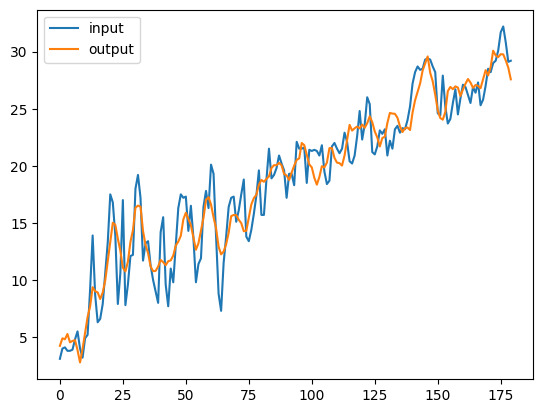

In [10]:
plt.plot(input_x.detach()[0].numpy(), label='input')
plt.plot(output.detach()[0].numpy(), label='output')
plt.legend(loc="upper left")

### 異常値検出

テストデータを用いてoutputを求め比較する

In [11]:
input_x = []
test_X = []
input_x.append(test_x[0:180])
input_x.append(test_x[180:360])
test_X = np.array(input_x, dtype="float32")
input_test = torch.tensor(test_X, requires_grad = False)
model.eval()
with torch.no_grad():
  output = model(input_test)
pd.DataFrame(test_X)

,0,1,2,3,4,5,6,7,8,9,...,170,171,172,173,174,175,176,177,178,179
0,6.5,7.6,5.700000,5.700000,4.400000,5.8,7.7,6.600000,9.1,7.4,...,20.9,21.200001,23.5,20.4,21.700001,25.799999,25.4,26.6,26.200001,26.799999
1,27.5,27.5,27.700001,27.200001,26.799999,26.4,23.0,25.200001,27.4,27.4,...,7.7,9.400000,9.5,9.9,9.900000,10.200000,10.7,8.5,6.900000,8.100000


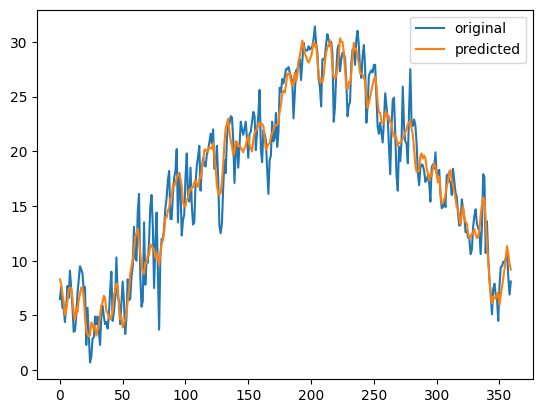

In [12]:
plt.plot(test_X.flatten(), label="original")
plt.plot(output.detach().numpy().flatten(), label="predicted")
plt.legend(loc="upper right")

予測値を求めて、二乗誤差を計算、正規化する

In [13]:
test = test_X.flatten()
predict = output.detach().cpu().numpy().flatten()
total_score = np.square(test - predict)
# 閾値は訓練側の復元誤差から決める実用上は別の正常検証期間を使う
model.eval()
with torch.no_grad():
  normal_input = torch.tensor(train_X, dtype=torch.float32)
  normal_output = model(normal_input)
normal_score = (normal_input - normal_output).square().numpy().flatten()
threshold = np.quantile(normal_score, 0.99)
print("異常候補の数:", np.count_nonzero(total_score > threshold))


異常候補の数: 7


どの程度の誤差があるかをグラフで表示する
- 今回の閾値は訓練側の誤差から求めた99%点である
- テスト誤差の最大値で正規化して0.5を選ぶ方法では、未知の期間に同じ基準を適用できない
- 同じ訓練データからの閾値は楽観的になり得るので、実用上は別の正常検証期間で調整する


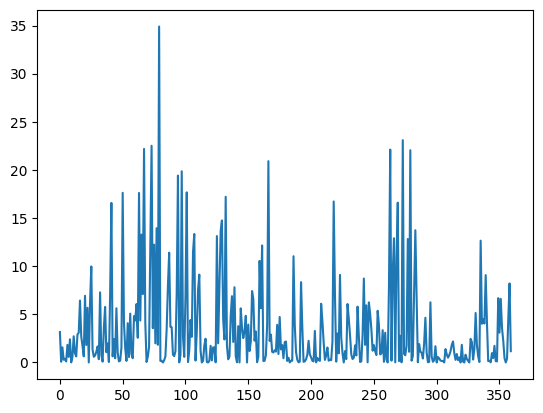

In [14]:
plt.plot(total_score)

ここまでは、なんら従来と変わらないであろう

# 課題1(AEの基本)

その他の気象データや株のデータ(予測はRNNの章で扱う)を用いて、異常値を検出しなさい

# MNISTによるAutoEncoder

このあと、CVAEと呼ばれる発展版を学ぶため、比較のため、MNISTでもAEを実装しておく

また、潜在空間について理解を深める

セルの実行でエラーが出た時は、ランタイムを再起動して最初からやり直す必要があるかもしれないので注意すること
- リセットではない
- 例えばパラメータを変更する、記述を修正するなどして、再度試す場合は注意すること

今回はfrom importを多く用いて、記述性を上げている
- コード記述上は、こちらの方が短く済む
- 但し、一度しか使わない内容について用いるのは考えるべきところ

In [15]:
import os
import numpy as np
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST
from torchvision.utils import save_image
import matplotlib.pyplot as plt
# GPU存在のチェック
device = torch.device(cuda if torch.cuda.is_available() else "cpu")
print(device)
#num_epochs = 100
num_epochs = 20
batch_size = 128
learning_rate = 0.001
if not os.path.exists('mydata'):
  os.mkdir('mydata')

cuda:0


データ変換関数で正規化を行う
- MNISTはToTensor()により[0, 1]の値として得られる
  - コメントアウトしているが、外すことで[-1, 1]の範囲に変換する
  - コメントアウトを外す場合、`def to_img(x):`についてもコメントを外して[0, 1]の値に変換しなおす必要がある
    - コメントアウトを忘れると画像が白飛びする
  - 変換しなくても学習は進み、その方がロスは小さくなる傾向にある

In [16]:
img_transform = transforms.Compose([
  transforms.ToTensor(),
#  transforms.Normalize((0.5), (0.5))
])
train_dataset = MNIST('mydata', download=True, transform=img_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.48MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.08MB/s]


AutoEncoderモデルを定義する
- 内部空間$z$を利用するため、Encoder と Decoder を独立して定義し、後でDecoderのみ利用できるようにする
- EncoderとDecoderで$w$や$b$などのパラメータは独立させて個別に学習させる

EncoderとDecoderは完全に対称な形としている
- これが必須というわけではないが、AutoEncoderの思想では対象が望ましいであろう

全結合網で784次元から $\rightarrow$ 128 $\rightarrow$ 64 $\rightarrow$ 12 $\rightarrow$ 2次元まで圧縮している
- 2次元では平面上に描画できるため視覚化しやすい
- Decoderは対称に構築している

最終段はいろいろ選んで遊んでみると良いであろう
- `transforms.Normalize((0.5), (0.5))`する場合は入力画像を[-1, 1]に標準化していることから、出力の範囲が [-1, 1]である活性化関数tanhを利用する
  - とはいえ、実はどちらもそれほど変わらない
- この例ではReLUも比較できるが、訓練損失が素早く下がることだけでは優劣を決められない
  - 出力範囲、検証データの復元誤差、画像品質を合わせて確認する


In [17]:
class AE(nn.Module):
  def __init__(self):
    super(AE, self).__init__()
    self.encoder = nn.Sequential(
      nn.Linear(28 * 28, 128),
      nn.ReLU(True),
      nn.Linear(128, 64),
      nn.ReLU(True),
      nn.Linear(64, 12),
      nn.ReLU(True),
      nn.Linear(12, 2))
    self.decoder = nn.Sequential(
      nn.Linear(2, 12),
      nn.ReLU(True),
      nn.Linear(12, 64),
      nn.ReLU(True),
      nn.Linear(64, 128),
      nn.ReLU(True),
      nn.Linear(128, 28 * 28),
#      nn.Tanh() # (*)
#      nn.Sigmoid() # (*)
#      nn.ReLU(True) # (*)
    )
  def forward(self, x):
    x = self.encoder(x)
    x = self.decoder(x)
    return x
model = AE().to(device)
model

AE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=64, out_features=12, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=12, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=12, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=12, out_features=64, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=128, out_features=784, bias=True)
  )
)

変換したテンソルを元の画像[0,1]に戻す関数を定義する
- `#  transforms.Normalize((0.5), (0.5))`と対であり、正規化しない場合は`(*)`の行をコメントアウトする

In [18]:
def to_img(x):
#  x = 0.5 * (x + 1) # (*)
#  x = x.clamp(0, 1) # (*)
  x = x.view(x.size(0), 1, 28, 28)
  return x

訓練ループで定期的に生成画像を出力している
- 現在エポック数は20であるが、訓練損失の低下だけでは過学習の有無を判断できない
  - 検証データの復元誤差も確認する
  - 時間に余裕があるならば、思い切って200などにするとよいであろう
- 損失関数は入力と出力の間の平均二乗誤差としている
  - 画像として出力と入力の画素値が一致するように学習がすすむ
最後に、学習したネットワークをモデルとして保存している
- 工夫として最もロスが小さかったモデルのみ覚えるという技も使える
  - ロスを求めて、ロスの最小値を管理し、それよりも小さい場合のみ保存するという手法
  - さらに、GPU用とCPU用を保存している
  - 装置ごとに保存し直すことは必須ではなく、`state_dict`を読み込む際に`map_location`で装置を指定できる
    - ここでは、両方保存している
    - CPUが選択されるとGPUもCPUモデルが保存される
- 特に保存する必要はないが、こういうこともできるということで

In [19]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),
    lr=learning_rate, weight_decay=1e-5)
loss_list = []
model.train()
for epoch in range(num_epochs):
  for data in train_loader:
    img = data[0]
    x = img.view(img.size(0), -1).to(device)
    xhat = model(x)
    # 出力画像（再構成画像）と入力画像の間でlossを計算
    loss = criterion(xhat, x)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # logging
    loss_list.append(loss.item())
  print('epoch [{}/{}], loss: {:.4f}'.format(
    epoch + 1, num_epochs, loss.item()))
    # 10エポックごとに再構成された画像（xhat）を描画する
  if epoch % 5 == 0:
    pic = to_img(xhat.detach().cpu())
    save_image(pic, 'mydata/image_{}.png'.format(epoch))

np.save('mydata/loss_list.npy', np.array(loss_list))
torch.save(model.state_dict(), 'mydata/autoencodergpu.pth')
torch.save(model.to('cpu').state_dict(), 'mydata/autoencodercpu.pth')

epoch [1/20], loss: 0.0536
epoch [2/20], loss: 0.0444
epoch [3/20], loss: 0.0465
epoch [4/20], loss: 0.0449
epoch [5/20], loss: 0.0434
epoch [6/20], loss: 0.0418
epoch [7/20], loss: 0.0413
epoch [8/20], loss: 0.0436
epoch [9/20], loss: 0.0433
epoch [10/20], loss: 0.0401
epoch [11/20], loss: 0.0414
epoch [12/20], loss: 0.0378
epoch [13/20], loss: 0.0398
epoch [14/20], loss: 0.0397
epoch [15/20], loss: 0.0413
epoch [16/20], loss: 0.0423
epoch [17/20], loss: 0.0393
epoch [18/20], loss: 0.0363
epoch [19/20], loss: 0.0389
epoch [20/20], loss: 0.0383


実験結果としてまずはロス曲線を示す
- 細かいことだが、横軸はiterationである
- エポック毎に表示する場合はepoch、ミニバッチである場合はiterationとする

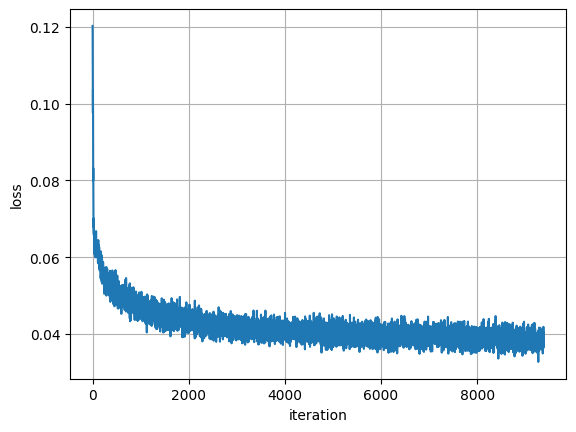

In [20]:
loss_list = np.load('{}/loss_list.npy'.format('mydata'))
plt.plot(loss_list)
plt.xlabel('iteration')
plt.ylabel('loss')
plt.grid()

学習途中で保存した画像を確認する
- 学習が進むにつれ、明瞭な画像が得られていることが確認できるであろう
- 入力画像も保存し、対応させるようにすると興味深いであろう
- さらに学習を進めていくと精細さは向上するが、全体的にくっきりとした画像を得るのは困難である
  - 敵対的生成ネットワーク(Generative Adversarial Networks:GAN)はこの点を加速化できるが、学習の安定化が難しい
  - 先に示した顔画像が明瞭なのは、GANを利用しているためである

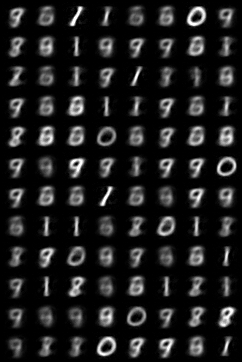

In [21]:
from IPython.display import Image
Image('mydata/image_0.png')

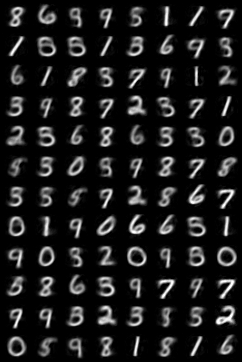

In [22]:
Image('mydata/image_10.png')

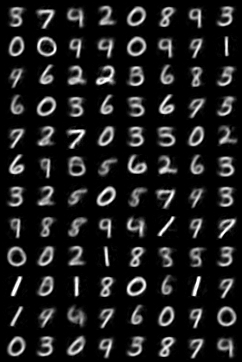

In [23]:
Image('mydata/image_15.png')

潜在空間の可視化

- model2に学習済みモデルを読み直す
  - 特に必要ないが、こういうこともできるということで
  - `(*)`ではGPUモデルを読み出すようになっているが、実行環境に応じて切り替える必要がある
- テストデータ10000画像をEncoderだけを用いて$z$つまり
潜在空間にマッピングする
- $z$内での各画像の分布を可視化する
- モデル定義において、EncoderとDecoderを別個に定義しているため`model.encoder()`とすることでエンコーダのみ呼び出すことができる

In [24]:
test_dataset = MNIST('mydata', download=True, train=False, transform=img_transform)
test_loader = DataLoader(test_dataset, batch_size=10000, shuffle=False)
model2 = AE().to(device) # 784次元ベクトルを2次元ベクトルへ圧縮
model2.eval()
model2.load_state_dict(torch.load('mydata/autoencodergpu.pth', map_location=device, weights_only=True)) # (*)
data = next(iter(test_loader))
img = data[0]
x = img.view(img.size(0), -1)
x = x.to(device)
with torch.no_grad():
  z = model2.encoder(x)
z = z.detach().cpu().numpy()
z.shape

(10000, 2)

zは (10000, 2) であることがわかる
- つまり784次元の画像が2次元データに圧縮されている

この考え方は後述する多様体仮説と関係する
- 今回のMNISTの結果だけで、実際にスイスロールを展開したと証明できるわけではない
- 潜在空間の座標や向きは初期値などで変わり得る


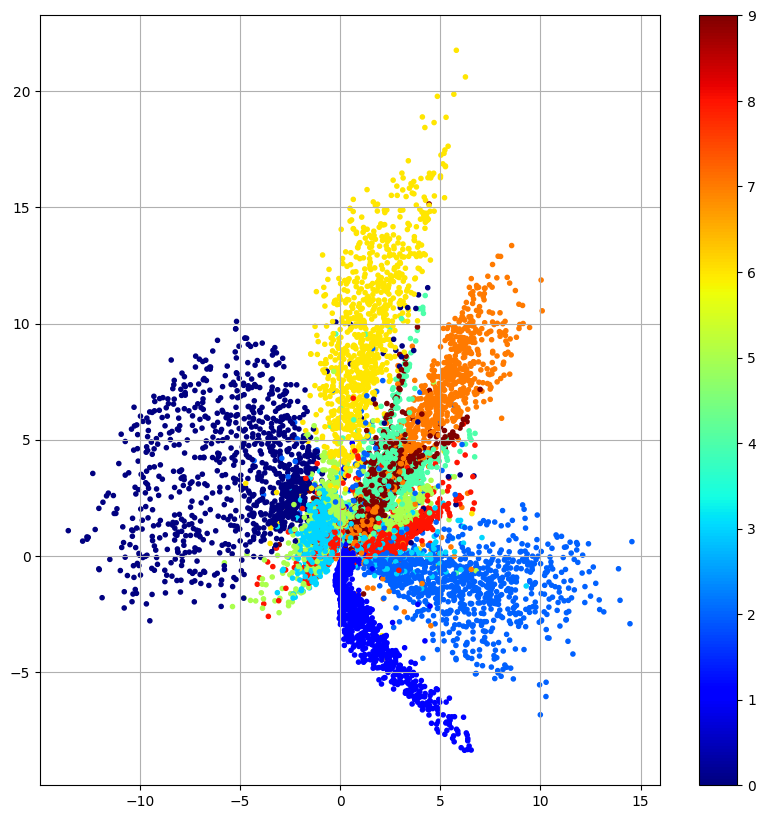

In [25]:
import pylab
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
plt.scatter(z[:, 0], z[:, 1], marker='.', c=data[1].numpy(), cmap=pylab.cm.jet)
plt.colorbar()
plt.grid()

各数字のデータがクラスタになって**混ざらずに(実は一部重なってはいるが)**ばらついて分布している
- つまり、2次元の潜在空間上でも各数字を分離できていることを意味する
  
- 潜在空間の分布が±20程度の範囲に拡散している
  - これはAutoEncoderであるためで、VAEであればN(0, I)内に収まる

さらに時間がかさむが、もう少しファンシーな表示を行う

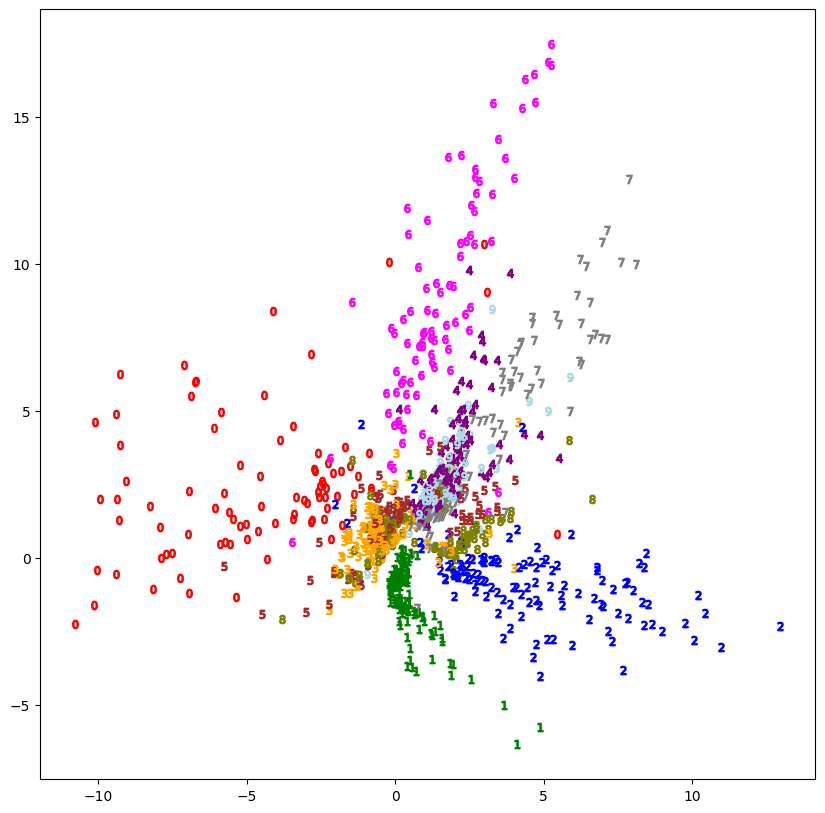

In [26]:
from random import random
colors = ["red", "green", "blue", "orange", "purple", "brown", "fuchsia", "grey", "olive", "lightblue"]
plt.figure(figsize=(10,10))
points = z[:1000]
for p, l in zip(points, data[1]):
  plt.scatter(p[0], p[1], marker="${}$".format(l), c=colors[l])

さて、可視化はできたが、密集する場所が存在し、密集地域での分布がわかりにくい
- これは、多次元を無理やり2次元に落とし込めた際に、空間の曲げ方が**密度が一定になるように次元削減する・曲げる**という制約項もなく、成り行きで次元圧縮しているためである
- 実際には拡大すれば分離されていることがわかる

# (参考)t-SNE

さて、本授業の範囲外であるが、単純に次元削減したい場合は、t-SNEが利用できる
  - 興味がある場合は調べると良いであろう
  - 2次元/3次元程度に圧縮する場合は有効であるが、複雑な場合は別の方法を選択したほうがよい
  - MNISTはt-SNE向きである
- はっきり言えば、2次元3次元の可視化であればt-SNEを利用するべき

サンプルコードを示すが、よっぽどきれいに分類できていることがわかる
- 似ている文字のグループが近くに存在することもわかる
- ただし逆変換を提供しないため、モーフィングなどの処理はできない

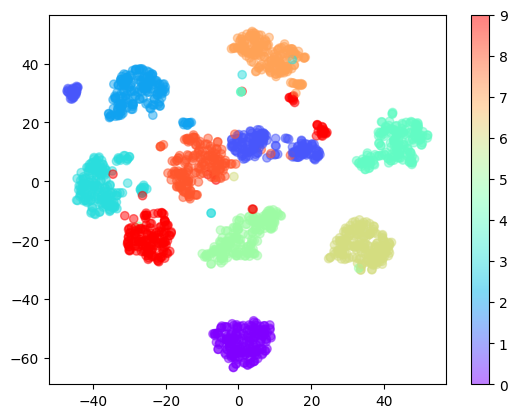

In [27]:
from sklearn import random_projection
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

digits = datasets.load_digits()

X_TSNEprojected = TSNE(n_components=2, random_state=0).fit_transform(digits.data)
X_Gprojected    = random_projection.GaussianRandomProjection(n_components=2).fit_transform(digits.data)
X_Sprojected    = random_projection.SparseRandomProjection(n_components=2).fit_transform(digits.data)

plt.scatter(X_TSNEprojected[:,0], X_TSNEprojected[:,1], c=digits.target,alpha=0.5, cmap='rainbow')
plt.colorbar()

外れるついでに、どんどん道にそれる

Google Colaboratoryの真のパワーを見てみよう

今回はPyTorch標準の `torch.utils.tensorboard.SummaryWriter` を用いる
- `add_scalar` で損失、`add_image` で画像、`add_embedding` で埋め込みなどを記録できる
- 大規模学習では条件ごとにログの保存先を分けると比較しやすい
- TensorFlowの `model.fit` のcallbackと、PyTorchの学習ループからログを書く方法を区別する


In [28]:
%pip install -q tensorboard


ログファイルの保存場所を指定する
- pythonの中から指定するために、SummaryWriterを導入して指定する

In [29]:
from torch.utils.tensorboard import SummaryWriter
writer1 = SummaryWriter()
writer2 = SummaryWriter(log_dir='logs/image')
writer3 = SummaryWriter(comment='loss function')


PyTorchを導入するが、あくまでもMNISTのデータをとるためと、データを食わせるため

In [30]:
import torch
import torchvision
from torchvision import datasets, transforms
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='mydata',
                               train=True,
                               transform=transform,
                               download=True)
test_dataset = datasets.MNIST(root='mydata',
                              train=False,
                              transform=transform)
batch_size = 1000
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)
images, labels = next(iter(train_loader))

データを保存する

In [32]:
images, labels = next(iter(train_loader))
mat_img = images.view(-1, 28*28)
meta_labels = [str(x) for x in labels.numpy().tolist()]
with SummaryWriter(log_dir='logs/projector') as w:
  w.add_embedding(mat_img, metadata=meta_labels, label_img=images)

さぁ、お楽しみだ
- PROJECTORが選択できる(出ない場合はリロードすること)
- T-SNEを選んで楽しもう
- テレビや動画でこのような画面をよく見るであろう、そう大したことはしていないのだ
  - 仰々しく、さも偉そうに見せて、お金を取ってくる、これが悪いコンサル、合法詐欺師だ

"Your browser or device does not have WebGL enabled. Please enable hardware acceleration, or use a browser that supports WebGL."というエラーが表示される場合は、https://get.webgl.org/ こちらのサイトにアクセスして、WebGLの対応状況を調べること
- **実行後、一度リロードボタンを押す必要がある**
- Google Chromeであれば問題なく見えるはず
- 見えない場合は、Chromeの設定、システム、ハードウェアアクセラレーションが使用可能な場合は使用する」をONにすること
- それでも見えない場合は、GPUが新しいなど、未対応である場合がある
  - Firefoxなどブラウザを変えると見える場合がある
- 次のような画面を見ることができる

<img src="http://class.west.sd.keio.ac.jp/dataai/text/tensorb-img.png" width=600>


In [33]:
%load_ext tensorboard
#TensorBoard起動（表示したいログディレクトリを指定）
%tensorboard --logdir=logs

Output hidden; open in https://colab.research.google.com to view.

# Variational Autoencoder(VAE)

AutoEncoderが目指すところは理解できたであろう

しかしながら、先ほどの顔のモーフィングのように**連続して移動できる**保証はどこにあるのだろうか？
  - 潜在空間を埋め尽くすように、各顔の特徴がマッピングされるとは限らないのではないか？
  - その通りで、実際にAutoEncoderは学習させてうまく生成できるが、復元や表現学習には有用だが、潜在空間へ任意の乱数を入れる生成には別の工夫が必要である
  - 潜在空間をみても、隙間が多く、その隙間に位置する潜在空間ではどのような文字が生成されるかがわからない
    - そもそも文字ではなくなってしまうが

<img src="http://class.west.sd.keio.ac.jp/dataai/text/aefig.png" width=300>

この図のように、潜在空間をどのようにするか、については制御していない

そこで、VAEはKingma & Welling(2014)により提案された手法であり、潜在変数$z$の事前分布を例えば$\mathcal{N}(0,I)$とし、入力ごとの近似事後分布$q_\phi(z|x)$からサンプリングして、データの生成過程を学習する

なぜそれでよいのかについて、以下説明する

<img src="http://class.west.sd.keio.ac.jp/dataai/text/vaefig.png" width=300>

VAEでは、Encoderにおいて平均ベクトル$\mu$と標準偏差ベクトル$\sigma$を学習し、これらの平均ベクトル、分散ベクトルから得られる多変量ガウス分布から潜在変数$z$をサンプリングする
- つまり、$z\sim\mathcal{N}(\mu,\mathrm{diag}(\sigma^2))$とする
- このベクトル$z$が次元圧縮後のベクトルとなる

このようなアイデアは常に「学習できること」が重要であり、単純にこのままのモデルでは誤差逆伝播ができない
- $\mu$と$\sigma$で得られるガウス分布から$z$をサンプリングする点で、逆伝播の演算ができなくなっている

VAEはその後も多くの派生モデルを生み出した
- **VQ-VAE**(Van Den Oord et al.、2017): 連続的な潜在空間の代わりに離散的なコードブック(codebook)を用い、画像・音声生成で高い性能を達成
- **VQ-VAE-2**(Razavi et al.、2019): 階層的な量子化により大規模画像生成を実現
- これらは後のDALL-E(Ramesh et al.、2021)の基盤技術となった

## Reparametrization Trick

逆伝播の演算ができない問題を解決するため、実際のVAEではReparametrization Trickが用いられている

<img src="http://class.west.sd.keio.ac.jp/dataai/text/vaetrick.png" width=300>

$z$をサンプリングで求めずに、
$z=\mu+\sigma\odot\epsilon$、$\epsilon\sim\mathcal{N}(0,I)$ と書き換える
- $\odot$は要素ごとの積であり、対角ガウス分布の場合は同じ分布を正確に表現する近似ではない

実際のネットワーク構造は下記のようになる

<img src="http://class.west.sd.keio.ac.jp/dataai/text/reptrik.webp" width=300>

$z\sim\mathcal{N}(\mu,\mathrm{diag}(\sigma^2))$を直接扱わず、$\epsilon∼N(0,I)$にてノイズを発生させ、図に示すように$z=\mu(X)+\epsilon \cdot \sigma(X)$という形でつなげることで、**乱数$\epsilon$を固定した計算について青い矢印を逆にたどり、$\mu$と$\sigma$へ勾配を伝える**という工夫がなされている
  - 黒いパスは逆伝播では利用しない

## Regularization Parameter

VAEは復元誤差と、近似事後分布を事前分布へ近づける項を合わせて学習する
- 単にノイズを足すだけではVAEの目的関数にはならない

最小化する損失は、負のELBO(Evidence Lower Bound)として次の形になる
$$
L(x)=-\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]
+D_{KL}(q_\phi(z|x)\Vert p(z))
$$
- 第1項は復元に対応する負の対数尤度である
- 第2項は非負のKLダイバージェンスであり、最小化する損失ではプラスで加える
- ELBOを最大化する式ではKL項がマイナスとなる最大化と最小化を混同しない

対角ガウス分布と標準正規分布の場合は、
$$
D_{KL}=\frac{1}{2}\sum_j(\mu_j^2+\sigma_j^2-1-\log\sigma_j^2)
$$
となる
- 平均を0、分散を1へ近づける方向に働くが、復元との釣り合いがあり、一致を強制するものではない
- KL項の係数を変える$\beta$-VAEや、posterior collapseを抑える工夫もある


# Conditional Variational Auto Encoder (CVAE)

CVAEは、VAEに対して正解ラベルも付与して学習を行う手法
- Encoder、Decoder両方に正解ラベルを付与して学習させている

<img src="http://class.west.sd.keio.ac.jp/dataai/text/cvaefig.png" width=300>

その利点は次の通り
- Encoderで次元削減するとき、画像データだけでなくそのラベルを反映させることができる
- Decoderでデータ生成するとき、欲しいデータの状態を指定することができる
- 半教師ありに拡張する方法もあるが、本テキストの実装は全ての入力にラベルを与える  
後でクリアになるのでとりあえずそういうものだと理解しておく

## 具体的な効果

例えば、MNISTを$z$が2次元のVAEで学習させることを考える

- 訓練データのデータセットを入れて潜在変数を求めこれを順番に座標系にプロットする
- VAEの場合、訓練データのMNISTデータセットが2次元の正規分布に従う円の上に散らばるようになる
  - そうなるように確率分布を想定した
- すると**同じクラスラベルのデータが近いところに集まっている**ことが確認でき、点で見えているが、点と点の間もそれにふさわしい画像を表す$z$で埋め尽くされているであろうと考えられる
  - VAEは正規分布に従う乱数を学習時に取り入れることで、この乱数の乱雑性により似た形状を近くに寄せる効果を与える
  - 同じ画像を同じ値で表現せず、敢えて毎回散らして学習させることで、**この画像の表現範囲はこの辺り**と明確に定まらないようにして、あえてぼんやり学習させる
  - すると、それぞれのぼんやりの重なりが現れるようになり、連続的に推移できるようになる

MNISTをVAEで学習させた例が次の図で、図の点は訓練データを入力した際の$z$の値のプロットを表している

<img src="http://class.west.sd.keio.ac.jp/dataai/text/vaemnist.png" width=300>

すると、先ほどの顔匿名化と同じことが起こる(というか、顔匿名化はこの技術の応用なのだが)
- 例えば、0から7に至る線分上の点、つまり内分点を順番に求めて、デコーダだけ使って画像を得ると、次のようになる

<img src="http://class.west.sd.keio.ac.jp/dataai/text/vaemnistmove.png" width=300>

実際に得られる出力は次の通り

<img src="http://class.west.sd.keio.ac.jp/dataai/text/vaemove.gif" width=100>

0から滑らかに、6、2、8、9、4、7のように推移するのがわかる
- 4と9の間を通るので、4と9が混ざったような数字が出るのも、その通り

さらに$z$の空間に直接格子状に点を作って次々と代入すると、マッピング図が得られ、この上の0から7へ移動させたことが明確となる

<img src="http://class.west.sd.keio.ac.jp/dataai/text/vaemnistmap.webp" width=500>

マップ上で、0から1、1から2、2から3と動かしていくと、数字が滑らかに変化するような動画が得られる
- ストップウォッチや時計に利用すると、若干カッコいい？
- 芸術家でさえAIを使う時代なのだ


## 多様体仮説

そもそも、なぜこういうことができるのか？を根本的に説明することは実はできていないといってよい
- なぜか現実世界はそういうスパースな状況に見えて、集まっているのである
- 宇宙の大構造のようなイメージか？

その説明の一つが次の**多様体仮説**である

- 多様な次元をもつデータがあるとしても、そのデータは少ない次元で表現できたとする(実際に学習できたし、できてしまう)

  - このとき、意味のあるデータ、つまり訓練データにおける本質をとらえたデータは、高次元のデータの中でも局所的に固まっている
  - つまり、高次元で情報を見る(例えば、画像でMAEを算出する)よりも、その少ない次元での距離を測る方が類似しているものが見つかるといえる
- 例えば、ネズミとハスキー犬と白柴犬の写真があったとする
  - 画素でMAE計算すれば、色の近いネズミとハスキー犬が近いと判断してしまうであろう
  - 潜在空間$z$でみれば、ハスキー犬と白柴犬の方が近い
    - 同様に動物の特徴、例えば、足の長さや耳の長さ、胴体の形などの近しいものが並んでいくであろう
    - そうであるならば、$z$上の距離が、本質をついた差を表現していないか？ということになる

次の図は、多様体の考え方を説明するスイスロールの例について説明した図である
- 元の空間では、ロールの別の層にある点がユークリッド距離では近くなることがある
  - 曲面に沿った距離と元の空間での距離が違うことを、この例で確認できる
- ところがスイスロールのクリームの上では連続でその上で距離を測ることに意味がある、という考え方
- 多様体学習では、局所的な近さなどを利用して低次元の構造を調べる
  - カーネルトリックは特徴空間の内積を直接計算する別の考え方であり、スイスロールを開く方法と同一ではない
  - AutoEncoderの潜在距離が意味を持つかは、目的関数と学習データ、下流タスクで確認する

<img src="http://class.west.sd.keio.ac.jp/dataai/text/swissroll.webp" width=500>


# CVAEの実装

先にTensorBoardを見てしまうと、ビジュアル的にCVAEはしょぼく感じるかもしれないが、気合を入れなおして張り切って学ぼう

今回の目標は、「人の癖をくみ取ったフォントの自動生成」である

In [34]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
# ハイパーパラメータ集
SEED = 0
CLASS_SIZE = 10
BATCH_SIZE = 256
ZDIM = 16
NUM_EPOCHS = 50
# GPU存在のチェック
DEVICE = torch.device(cuda if torch.cuda.is_available() else "cpu")
print(DEVICE)
# シードの設定
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
# データセットとデータローダの準備
train_dataset = torchvision.datasets.MNIST(
  root='mydata', train=True, transform=transforms.ToTensor(), download=True,
)
train_loader = torch.utils.data.DataLoader(
  dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True,num_workers=0
)

cuda:0


## モデルの定義と処理記述

- AutoEncoderでは無理やり2次元に押し込めた
  - さすがにそれは無理があるので、今度は16次元への圧縮
  - ただし、そこから2次元ではなく16次元に圧縮する
- $z$の部分に、mean、lnvarを計算している部分がある
  - これが、VAEとCVAEに共通する部分である
```
self._to_mean = nn.Linear(hidden_units, zdim)
self._to_lnvar = nn.Linear(hidden_units, zdim)
```
および
```
mean = self._to_mean(h)
lnvar = self._to_lnvar(h)
```
において、先の説明通りの結合が構成されている
  - 残りの結合は、外部の記述上に存在する

入出力でCVAEならではの記述がされている
- `def encode(self, x, labels):`は、imageとlabelを引数とし、$\mu$と$\ln\sigma^2$を返す
- `def decode(self, z, labels):`は、`z = mean + std * epsilon`とラベルを入力とし、再構成された画像を返り値としている
- これらがCVAEの部分である

In [35]:
class CVAE(nn.Module):
  def __init__(self, zdim):
    super().__init__()
    self._zdim = zdim
    self._in_units = 28 * 28
    hidden_units = 512
    self._encoder = nn.Sequential(
      nn.Linear(self._in_units + CLASS_SIZE, hidden_units),
      nn.ReLU(inplace=True),
      nn.Linear(hidden_units, hidden_units),
      nn.ReLU(inplace=True),
    )
    self._to_mean = nn.Linear(hidden_units, zdim)
    self._to_lnvar = nn.Linear(hidden_units, zdim)
    self._decoder = nn.Sequential(
      nn.Linear(zdim + CLASS_SIZE, hidden_units),
      nn.ReLU(inplace=True),
      nn.Linear(hidden_units, hidden_units),
      nn.ReLU(inplace=True),
      nn.Linear(hidden_units, self._in_units),
      nn.Sigmoid()
    )
  def encode(self, x, labels):
    in_ = torch.empty((x.shape[0], self._in_units + CLASS_SIZE), device=DEVICE)
    in_[:, :self._in_units] = x
    in_[:, self._in_units:] = labels
    h = self._encoder(in_)
    mean = self._to_mean(h)
    lnvar = self._to_lnvar(h)
    return mean, lnvar
  def decode(self, z, labels):
    in_ = torch.empty((z.shape[0], self._zdim + CLASS_SIZE), device=DEVICE)
    in_[:, :self._zdim] = z
    in_[:, self._zdim:] = labels
    return self._decoder(in_)

PyTorchには、one-hotをワンライナーで構成する関数が準備されているので、今回はそれを利用する
- torch.eyeは対角のみ1で後は0の行列を生成するため、狙った行を選択するとone-hotになる

モデルの定義を行い、最適化にAdamを指定する

In [36]:
def to_onehot(label):
  return torch.eye(CLASS_SIZE, device=DEVICE, dtype=torch.float32)[label]
model = CVAE(ZDIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

実際の処理は次の通り

`mean` は平均、`lnvar` は分散の対数を表す
- `std = exp(0.5 * lnvar)` で標準偏差を求める
- `torch.randn_like(std)` により、各サンプル・各潜在次元で独立な乱数を、同じdevice・dtype上に生成する
- `z = mean + std * epsilon` として潜在変数を得る

ここでは、**バイナリクロスエントロピー(2値交差エントロピー)**を復元項として利用する
- 各画素の明るさを[0, 1]の値として扱う復元の仮定であり、画素を多クラス分類しているわけではない
- MSEも要素ごとに計算できるBCEを使う理由は、乱数をサンプルごとに計算するためではない
- 画素・潜在次元について和を取り、最後にバッチについて平均する

```python
loss = (kld + bce).mean()
```
- `kld` は正のKLダイバージェンス、`bce` は復元の負の対数尤度に対応する
- 潜在空間の意味や生成品質は、損失の低下だけでなく、再構成・サンプリング・下流タスクでも確認する


In [37]:
model.train()
for e in range(NUM_EPOCHS):
  train_loss = 0
  for i, (images, labels) in enumerate(train_loader):
    labels = to_onehot(labels)
    x = images.view(-1, 28*28*1).to(DEVICE) # 画像を1次元へ
    mean, lnvar = model.encode(x, labels) # ラベルと一緒にエンコーダへ
    std = torch.exp(0.5 * lnvar)
    epsilon = torch.randn_like(std) # 乱数を生成
    z = mean + std * epsilon # 潜在変数を変換
    y = model.decode(z, labels) # デコード
    # ロスを計算
    kld = 0.5 * (mean.pow(2) + lnvar.exp() - 1 - lnvar).sum(dim=1)
    bce = F.binary_cross_entropy(y, x, reduction='none').sum(axis=1)
    loss = (kld + bce).mean()
    # Update model
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss += loss.item() * x.shape[0]
  print(f'epoch: {e + 1} epoch_loss: {train_loss/len(train_dataset)}')

epoch: 1 epoch_loss: 185.46233751627605
epoch: 2 epoch_loss: 131.2800909830729
epoch: 3 epoch_loss: 117.61897197265625
epoch: 4 epoch_loss: 111.74917447102865
epoch: 5 epoch_loss: 108.33714141438801
epoch: 6 epoch_loss: 106.01299246826171
epoch: 7 epoch_loss: 104.42929916178386
epoch: 8 epoch_loss: 103.12368059082031
epoch: 9 epoch_loss: 102.00527048339843
epoch: 10 epoch_loss: 101.07902116699219
epoch: 11 epoch_loss: 100.33351318766276
epoch: 12 epoch_loss: 99.61574143880209
epoch: 13 epoch_loss: 99.04540176188151
epoch: 14 epoch_loss: 98.53968093261719
epoch: 15 epoch_loss: 98.073070707194
epoch: 16 epoch_loss: 97.6401625732422
epoch: 17 epoch_loss: 97.24022132568359
epoch: 18 epoch_loss: 96.84498905436197
epoch: 19 epoch_loss: 96.46726233723959
epoch: 20 epoch_loss: 96.26086473795573
epoch: 21 epoch_loss: 95.93617109375
epoch: 22 epoch_loss: 95.69970947265625
epoch: 23 epoch_loss: 95.45263729248047
epoch: 24 epoch_loss: 95.24636547851563
epoch: 25 epoch_loss: 94.9478801147461
epoch:

## CVAEを用いた実験

CVAEの特徴として、正解ラベルも一緒に学習されているため、
- zとして適当なランダムの値をいれる
  - 学習時に標準正規分布に近づける正則化を行うため、その事前分布からサンプルを取る
  - 学習した潜在変数の分布が完全に一致するとは限らず、生成結果も確認する
- ワンホットにした文字としての数字について、$z$を乱数で与えているため、様々な数字を自動生成する
  - GANのGeneratorと同じ感覚
  - もっともらしい、(誰も書いていない)嘘の数字をいくらでも作れるようになる

次の手順で試してみよう
- `getlabel=0`を修正
- セルを実行することで25個の数字を作成し表示させる
- 様々な数字の上にキャプションがある
  - Gen(作成した数字)[ID]であり、このIDは次で利用する

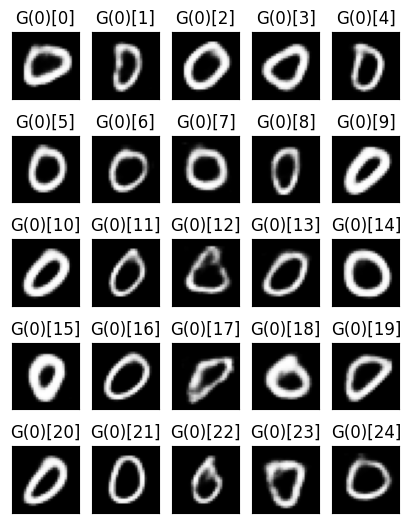

In [38]:
getlabel = 0
NUM_GENERATION = 25
model.eval()
allz = []
fig, ax = plt.subplots(5, 5, figsize=(5,6.5))
for i in range(NUM_GENERATION):
  z = torch.randn(ZDIM, device=DEVICE).unsqueeze(dim=0)
  label = torch.tensor([getlabel], device=DEVICE)
  with torch.no_grad():
    y = model.decode(z, to_onehot(label))
  y = y.reshape(28, 28).cpu().detach().numpy()
  # Save image
  ly = int(i/5)
  lx = i%5
  ax[ly, lx].imshow(y, cmap='gray')
  ax[ly, lx].set_title(f'G({label.cpu().detach().numpy()[0]})[{i}]')
  ax[ly, lx].tick_params(
    labelbottom=False,
    labelleft=False,
    bottom=False,
    left=False,
  )
  allz.append(z)
plt.show()

気になる形状の数字(フォントといってよいだろう)があれば、そのIDを調べる
- 細い、太い、斜め、三角、薄い、など特徴的なフォントを選ぶとわかりやすい

このIDがどういう潜在空間を持っているかを調べる
- つまり、これがその書体の特徴量であり、ID、固有番号である
- ここでは、先に示した通り16次元のベクトルで表現されている

In [39]:
z = allz[1]
z

tensor([[-0.1451,  0.5181,  0.3347,  1.3386,  0.7388,  1.4269,  1.1663, -1.0913,
          1.5669,  0.5678,  1.0523, -0.7148, -1.1664,  0.1706,  0.7228, -0.5982]],
       device='cuda:0')

次に、`genseries`関数を定義している
- この関数は、潜在空間の値を用いて、その書体で他の数字を生成することができる
- 次のセルを実行することで、選択したIDの形を維持した他の数字が表れるであろう

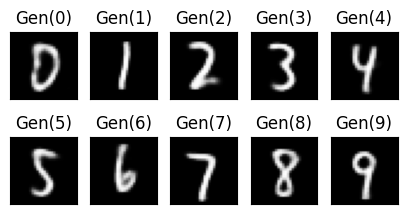

In [40]:
def genseries(z):
  model.eval()
  fig, ax = plt.subplots(2, 5, figsize=(5,2.5))
  for label in range(CLASS_SIZE):
    with torch.no_grad():
      y = model.decode(z, to_onehot(label))
    y = y.reshape(28, 28).cpu().detach().numpy()
    # Save image
    ly = int(label/5)
    lx = label%5
    ax[ly, lx].imshow(y, cmap='gray')
    ax[ly, lx].set_title(f'Gen({label})')
    ax[ly, lx].tick_params(
      labelbottom=False,
      labelleft=False,
      bottom=False,
      left=False,
    )
  plt.show()
genseries(z)

## 手書き文字の潜在空間とその潜在空間を用いた数字生成

さて、次に自分の手書き文字の潜在空間を調べる

次の手順で試してみよう
- まず「それなりにちゃんとした書体で手書き数字を準備する」
  - 紙に書いて写メでもよいし、ペイントブラシなどのアプリで描いてもよい
  - そのデータをgifやpngで保存する(ファイル名は英語のほうが問題が少ない)
  - そのファイルを左のフォルダの中にドラッグする
  - ドラッグしたら、次のセルの中の
 ```
 my_fig = Image.open("mytest.jpg")
 ```
 の部分にあるファイル名を、保存したファイル名で書き換える、**さらに**
 ```
 my_label = 2
 ```
 を**書いた数字の番号に書き換える**
  - セルを実行すると画面に表示される

  - さらにその次のセルを実行すると、保存したファイルの潜在空間$z$が表示される

なるべく特徴の現れやすい数字(2、3、4、5、6、8、9など)がよいであろう

In [41]:
if not os.path.exists('mytest.jpg'):
  !wget "https://drive.google.com/uc?export=download&id=1o1xxp0AtkCyjTTLW_oyqSKVHX5lLAJuN" -O mytest.jpg

--2026-10-06 03:04:35--  https://drive.google.com/uc?export=download&id=1o1xxp0AtkCyjTTLW_oyqSKVHX5lLAJuN
Resolving drive.google.com (drive.google.com)... 74.125.68.139, 74.125.68.113, 74.125.68.100, ...
Connecting to drive.google.com (drive.google.com)|74.125.68.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1o1xxp0AtkCyjTTLW_oyqSKVHX5lLAJuN&export=download [following]
--2026-10-06 03:04:36--  https://drive.usercontent.google.com/download?id=1o1xxp0AtkCyjTTLW_oyqSKVHX5lLAJuN&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.253.118.132, 2404:6800:4003:c04::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.253.118.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8108 (7.9K) [image/jpeg]
Saving to: ‘mytest.jpg’

mytest.jpg          100%[===================>]   7.92K  --.-KB/s    in 0s      

2026-1

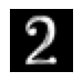

In [42]:
from PIL import Image
from PIL import ImageOps
my_label = 2
from scipy.ndimage import center_of_mass
my_fig = Image.open("mytest.jpg")
my_img = ImageOps.invert(my_fig.resize((28, 28)).convert("L"))
plt.figure(figsize=(0.8, 0.8))
plt.tick_params(
  labelbottom=False,
  labelleft=False,
  bottom=False,
 left=False,
)
plt.imshow(my_img, cmap='gray')

次のセルを実行すると、保存したファイルの潜在空間zが表示される

In [43]:
my_input = torch.tensor(np.array(my_img)/255.0, dtype=torch.float32)
x = my_input.view(1, 28*28).to(DEVICE)
label = torch.tensor(np.array(my_label), dtype=torch.long).to(DEVICE)
with torch.no_grad():
  mean, _ = model.encode(x, to_onehot(label))
z = mean
print(f'z = {z}')

z = tensor([[-1.1080,  1.9473, -1.1105, -0.1518, -0.6866,  2.4728, -0.0825,  0.0500,
          0.7486,  0.5751,  0.0534, -0.6185,  0.7021,  0.0369,  2.0008, -0.0577]],
       device='cuda:0')


保存した画像ファイルの潜在空間zが表示されるということは、それをもとに他の数字も作成できるということである
- 先ほど作成した関数genseriesを利用して表示する

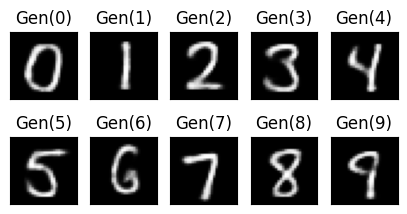

In [44]:
genseries(z)

# 課題2 (VAE)

CVAEを参考にしてVAEを実装しなさい

# 課題3 (CVAE)

CVAEの「手書き文字の潜在空間とそれを用いた数字生成」に従って、自分の手書きクセ字で数字を記載、写メるなどして画像を保存し、自分のクセ字をもとにした数字文字を生成しなさい

レポートには次の内容をそろえること
- 実行可能なノートブック
- 自分のクセ字
- 生成した数字の一覧(0から9まで)

# Interoperable Learningしてみよう

AutoEncoderは、潜在空間でカップリングされていれば、EncoderとDecoderは非対称でもよい

この性質は現代の多くのモデルで活用されている

## CLIP (Contrastive Language-Image Pre-training)
Radford et al.(2021)が提案したCLIPは、画像エンコーダとテキストエンコーダの出力を共通の潜在空間にマッピングし、対照学習(contrastive learning)で学習させたモデルである
- 画像とテキストのペアの類似度を潜在空間上の距離で測定する
- ゼロショット画像分類やテキストによる画像検索を可能にした
- CLIPについてはVision Transformerにおいて詳しく学ぶことができる

## Latent Diffusion / Stable Diffusion
Rombach et al.(2022)が提案したLatent Diffusion Modelは、AutoEncoderの潜在空間上で拡散過程を適用する手法である
- まずAutoEncoderで画像を潜在空間に圧縮する原論文ではKL正則化とVQ正則化の両方を検討し、Stable DiffusionではKL正則化のAutoEncoderが使われる
- 潜在空間上で拡散モデル(ノイズ除去)を動作させることで、計算効率を大幅に改善
- この手法がStable Diffusionの基盤技術であり、テキストから高品質画像を生成可能にした
- エンコーダ・デコーダ部分とノイズ除去部分が独立に設計できるため、まさにInteroperable Learningの実例といえる

## Masked Autoencoder (MAE)
He et al.(2022)が提案したMAEは、Vision Transformerの自己教師あり学習手法である
- 入力画像パッチの大部分(75%)をランダムにマスクし、残りから元画像を復元するAutoEncoderとして学習
- エンコーダはマスクされていないパッチのみ処理し、デコーダが全体を復元する
- 大規模な事前学習を効率的に行うことができ、下流タスクの精度を大幅に向上させた

これらのモデルに共通するのは、AutoEncoderの「圧縮→展開」の枠組みを基盤としつつ、各パーツを独立に設計・改良できるというInteroperabilityの思想である

**Representation Autoencoder(RAE)**[Zheng et al., 2025]では、DINO、SigLIP、MAEなどの事前学習済みエンコーダへ、復元を学習するデコーダを組み合わせる
- 狭い潜在空間へ圧縮するだけでなく、高次元の意味的な表現を画像生成に利用する
- Tong et al.(2026)は、RAEを大規模なテキストから画像への生成へ拡張している
- 潜在次元、ノイズの強さ、復元品質、生成品質を同時に設計する必要がある
- 研究で報告された条件での改善であり、全ての生成モデルでVAEが不要になったという結論ではない

CLIPは復元用デコーダを持たない対照学習モデルであり、AutoEncoderそのものではない
- 共通する表現空間を使う考え方と、どの損失で学習するかを区別する


# 参考文献

- Kingma, D. P. & Welling, M. (2014). "Auto-Encoding Variational Bayes." ICLR 2014.
- Sohn, K. et al. (2015). "Learning Structured Output Representation using Deep Conditional Generative Models." NeurIPS 2015.
- Van Den Oord, A. et al. (2017). "Neural Discrete Representation Learning." NeurIPS 2017.
- Razavi, A. et al. (2019). "Generating Diverse High-Fidelity Images with VQ-VAE-2." NeurIPS 2019.
- Ramesh, A. et al. (2021). "Zero-Shot Text-to-Image Generation." ICML 2021.
- Radford, A. et al. (2021). "Learning Transferable Visual Models From Natural Language Supervision." ICML 2021.
- He, K. et al. (2022). "Masked Autoencoders Are Scalable Vision Learners." CVPR 2022.
- Rombach, R. et al. (2022). "High-Resolution Image Synthesis with Latent Diffusion Models." CVPR 2022.
- Van der Maaten, L. & Hinton, G. (2008). "Visualizing Data using t-SNE." JMLR, 9, 2579-2605.

- Kingma, D. P. & Welling, M. (2014). [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114)
- Zheng, B. et al. (2025). [Diffusion Transformers with Representation Autoencoders](https://arxiv.org/abs/2510.11690)
- Tong, S. et al. (2026). [Scaling Text-to-Image Diffusion Transformers with Representation Autoencoders](https://arxiv.org/abs/2601.16208)
- PyTorch. [torch.utils.tensorboard](https://docs.pytorch.org/docs/2.14/tensorboard.html)
